In [1]:
import ast
import pandas as pd 
from datasets import load_dataset
import matplotlib.pyplot as plt 


dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date']= pd.to_datetime(df['job_posted_date'])
df['job_skills']= df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x) 

c:\Users\TOLU\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/lukebarousse/data_jobs/resolve/ed776e5a0a8c40ea9d5efbd800772ae52e140f3e/data_jobs.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since lukebarousse/data_jobs couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\TOLU\.cache\huggingface\datasets\lukebarousse___data_jobs\default\0.0.0\ed776e5a0a8c40ea9d5efbd800772ae52e140f3e (last modified on Thu Mar  5 19:06:55 2026).


In [2]:
df = df[df['job_title_short']=='Data Analyst']

In [15]:
df_exploded = df.explode('job_skills')

skills_stats = df_exploded.groupby('job_skills').agg( skill_count = ('job_skills','count'),
                                      median_salary = ('salary_year_avg','median'))
skills_stats=skills_stats.sort_values(by = 'skill_count', ascending = False).head(10)

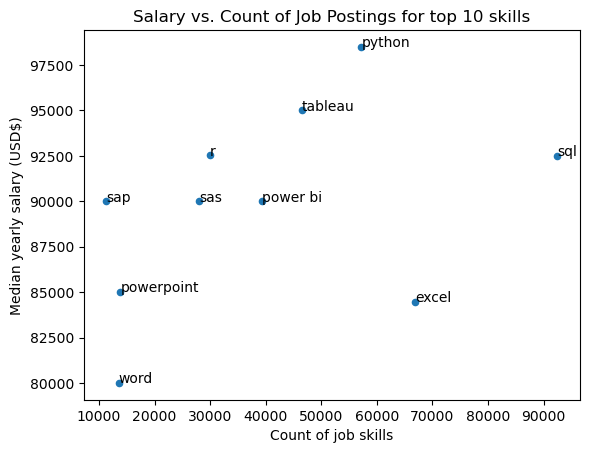

In [19]:
skills_stats.plot(kind='scatter', x= 'skill_count',y = 'median_salary')
plt.xlabel('Count of job skills')
plt.ylabel('Median yearly salary (USD$)')
plt.title('Salary vs. Count of Job Postings for top 10 skills')
plt.tight_layout
for i, txt in enumerate(skills_stats.index):
    plt.text(skills_stats['skill_count'].iloc[i],skills_stats['median_salary'].iloc[i], txt)
plt.show()